Loading model...
Model loaded successfully
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 efficientnetb2 (Functional  (None, 8, 8, 1408)        7768569   
 )                                                               
                                                                 
 global_average_pooling2d_3  (None, 1408)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_3 (Bat  (None, 1408)              5632      
 chNormalization)                                                
                                                                 
 dropout_3 (Dropout)         (None, 1408)              0         
                

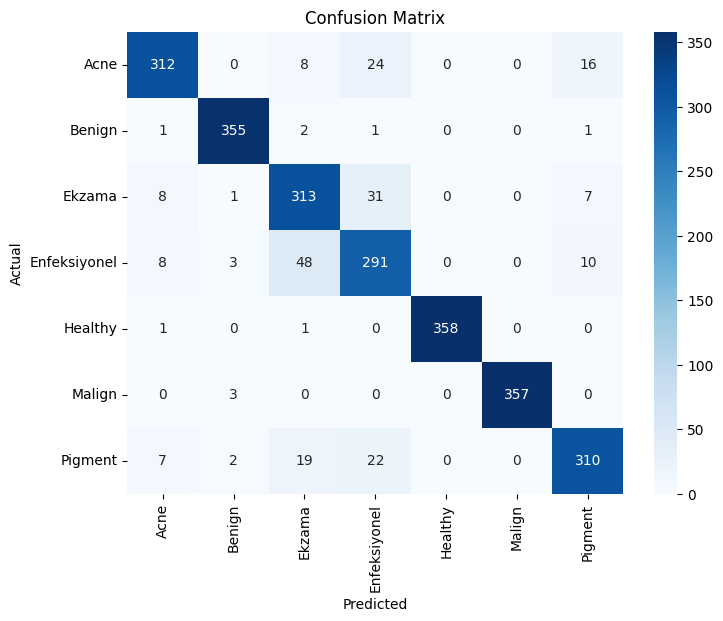


PER CLASS ACCURACY
Acne: 0.8667
Benign: 0.9861
Ekzama: 0.8694
Enfeksiyonel: 0.8083
Healthy: 0.9944
Malign: 0.9917
Pigment: 0.8611

ROC-AUC Score: 0.990691321281599

Prediction Confidence Stats
Average confidence: 0.9386862
Min confidence: 0.3348278
Max confidence: 0.99999714

DEPLOYMENT CHECK
Model performance is GOOD for deployment.


In [2]:
# IMPORT LIBRARIES

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input


# PATHS

MODEL_PATH = r"E:\Final Project\Main Folder\Notebooks\Models\skin7_finetuned.h5"
TEST_DIR = r"E:\Final Project\Main Folder\skin\skin_disease_classification\test"

IMG_SIZE = (256,256)   
BATCH_SIZE = 32
# LOAD MODEL

print("Loading model...")
model = load_model(MODEL_PATH)

print("Model loaded successfully")
print(model.summary())


# LOAD TEST DATASET

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_ds.class_names
NUM_CLASSES = len(class_names)

print("\nClasses:", class_names)

# APPLY SAME PREPROCESSING AS TRAINING

AUTOTUNE = tf.data.AUTOTUNE
test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.prefetch(AUTOTUNE)

# RUN PREDICTIONS

print("\nRunning predictions...")

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_prob.extend(preds)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# BASIC METRICS

accuracy = np.mean(y_true == y_pred)

precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# CLASSIFICATION REPORT

print("\n==============================")
print("CLASSIFICATION REPORT")
print("==============================")

print(classification_report(y_true, y_pred, target_names=class_names))


# 9️⃣ CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 🔟 PER CLASS ACCURACY

print("\n==============================")
print("PER CLASS ACCURACY")
print("==============================")

for i, class_name in enumerate(class_names):
    
    idx = y_true == i
    acc = np.mean(y_pred[idx] == i)

    print(f"{class_name}: {acc:.4f}")


# ROC-AUC SCORE (MULTI CLASS)

try:
    roc_auc = roc_auc_score(
        tf.keras.utils.to_categorical(y_true, NUM_CLASSES),
        y_prob,
        multi_class="ovr"
    )

    print("\nROC-AUC Score:", roc_auc)

except:
    print("\nROC-AUC could not be calculated.")


# PREDICTION CONFIDENCE CHECK

max_probs = np.max(y_prob, axis=1)

print("\nPrediction Confidence Stats")

print("Average confidence:", np.mean(max_probs))
print("Min confidence:", np.min(max_probs))
print("Max confidence:", np.max(max_probs))


# FINAL DEPLOYMENT CHECK

print("\n==============================")
print("DEPLOYMENT CHECK")
print("==============================")

if accuracy > 0.85:
    print("Model performance is GOOD for deployment.")
else:
    print("Model performance may need improvement.")

In [3]:
# print(model.input_shape)

(None, 256, 256, 3)


In [6]:
# Basic Setup

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32



In [8]:
# Dataset Loader


def load_dataset(dataset_path, img_size):

    ds = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_path,
        image_size=img_size,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = ds.class_names

    ds = ds.map(lambda x,y:(preprocess_input(x),y),
                num_parallel_calls=AUTOTUNE)

    ds = ds.prefetch(AUTOTUNE)

    return ds, class_names

In [9]:
# Run Predictions
def run_predictions(model, ds):

    y_true=[]
    y_pred=[]
    y_prob=[]
    images_store=[]

    for images,labels in ds:

        preds=model.predict(images,verbose=0)

        y_prob.extend(preds)
        y_pred.extend(np.argmax(preds,axis=1))
        y_true.extend(labels.numpy())
        images_store.extend(images.numpy())

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob),
        np.array(images_store)
    )


In [10]:
# ROC Curve per Disease (SKIN MODEL)
def plot_roc(y_true,y_prob,class_names):

    n_classes=len(class_names)
    y_true_bin=tf.keras.utils.to_categorical(y_true,n_classes)

    plt.figure(figsize=(8,6))

    for i in range(n_classes):

        fpr,tpr,_=roc_curve(y_true_bin[:,i],y_prob[:,i])
        roc_auc=auc(fpr,tpr)

        plt.plot(fpr,tpr,label=f"{class_names[i]} AUC={roc_auc:.3f}")

    plt.plot([0,1],[0,1],'k--')
    plt.title("ROC Curve per Disease")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


In [11]:
# Precision-Recall Curves (SKIN MODEL)
def plot_pr(y_true,y_prob,class_names):

    n_classes=len(class_names)
    y_true_bin=tf.keras.utils.to_categorical(y_true,n_classes)

    plt.figure(figsize=(8,6))

    for i in range(n_classes):

        precision,recall,_=precision_recall_curve(
            y_true_bin[:,i],
            y_prob[:,i]
        )

        ap=average_precision_score(
            y_true_bin[:,i],
            y_prob[:,i]
        )

        plt.plot(recall,precision,
                 label=f"{class_names[i]} AP={ap:.3f}")

    plt.title("Precision-Recall Curves")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()


In [12]:
# Misclassified Image Visualization (SKIN MODEL)
def show_misclassified(images,y_true,y_pred,class_names):

    mis=np.where(y_true!=y_pred)[0]

    print("Total misclassified:",len(mis))

    plt.figure(figsize=(12,10))

    for i,idx in enumerate(mis[:12]):

        plt.subplot(3,4,i+1)

        img=images[idx]
        img=(img-img.min())/(img.max()-img.min())

        plt.imshow(img)

        plt.title(
            f"T:{class_names[y_true[idx]]}\n"
            f"P:{class_names[y_pred[idx]]}",
            fontsize=9
        )

        plt.axis("off")

    plt.show()


In [13]:
# Model Reliability Analysis (SKIN MODEL)
def reliability_analysis(y_prob):

    confidence=np.max(y_prob,axis=1)

    plt.hist(confidence,bins=20)
    plt.title("Prediction Confidence Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Frequency")
    plt.show()

    print("Average confidence:",np.mean(confidence))
    print("Min confidence:",np.min(confidence))
    print("Max confidence:",np.max(confidence))

In [16]:
# Calibration Curve 

# Checks how reliable predicted probabilities are.

from sklearn.calibration import calibration_curve

def plot_calibration(y_true,y_prob):

    confidence=np.max(y_prob,axis=1)
    predictions=np.argmax(y_prob,axis=1)

    correct=(predictions==y_true)

    prob_true,prob_pred=calibration_curve(
        correct,
        confidence,
        n_bins=10
    )

    plt.plot(prob_pred,prob_true,marker='o')
    plt.plot([0,1],[0,1],'--')

    plt.xlabel("Predicted probability")
    plt.ylabel("True probability")

    plt.title("Calibration Curve")
    plt.show()


In [17]:
# Error Analysis per Disease (BOTH MODELS)
def error_analysis(y_true,y_pred,class_names):

    cm=confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Error Analysis Confusion Matrix")
    plt.show()

Found 2520 files belonging to 7 classes.


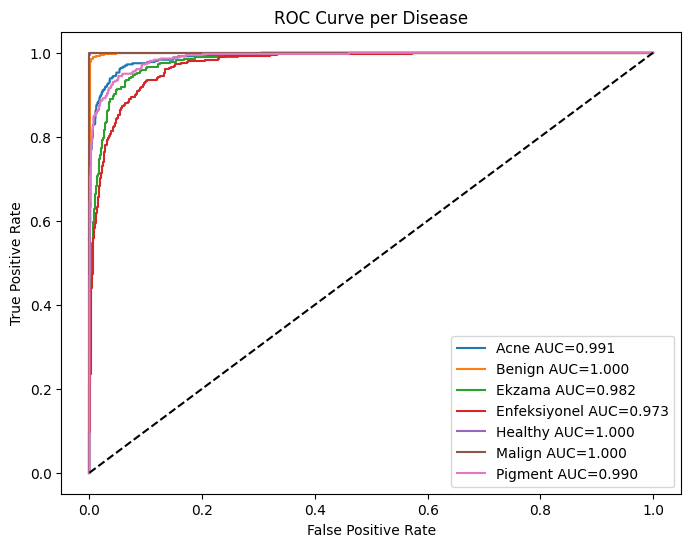

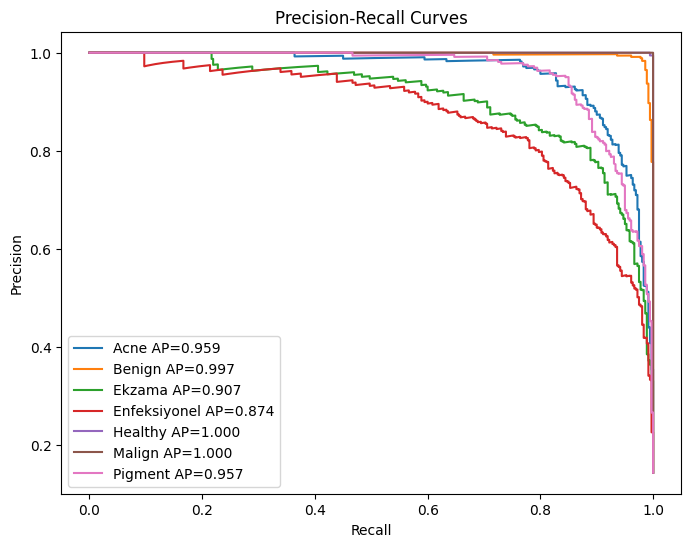

Total misclassified: 224


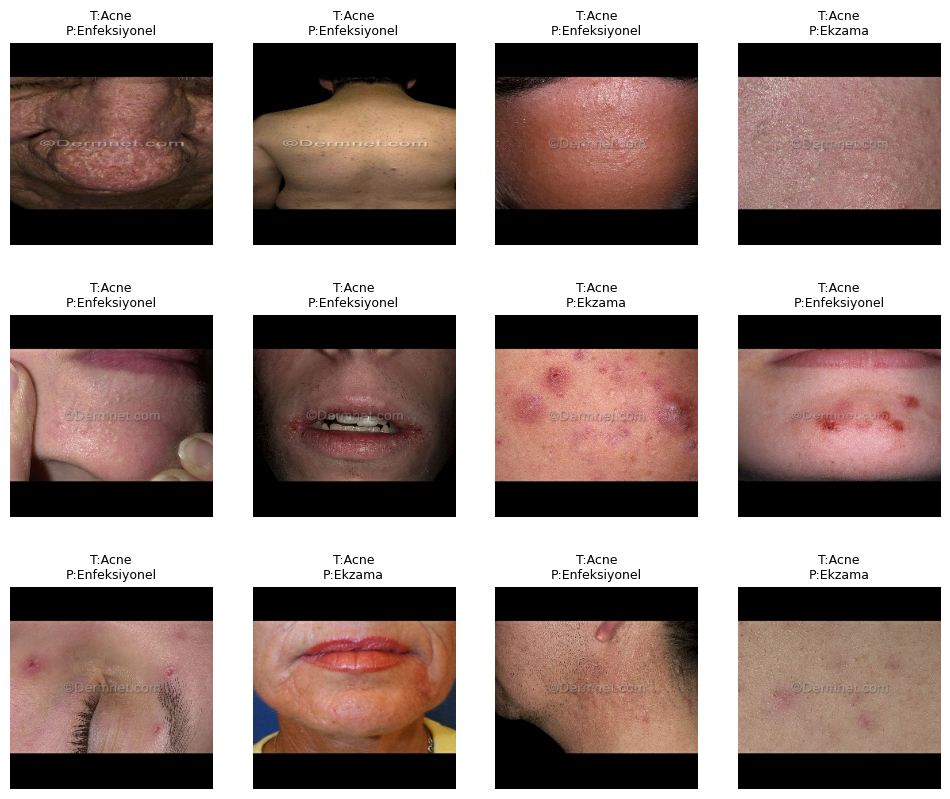

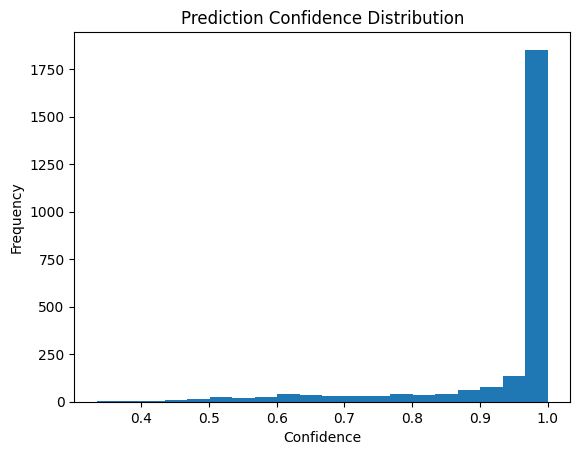

Average confidence: 0.9386862
Min confidence: 0.3348278
Max confidence: 0.99999714


In [18]:
skin_model = load_model(
r"E:\Final Project\Main Folder\Notebooks\Models\skin7_finetuned.h5"
)

ds,classes = load_dataset(
r"E:\Final Project\Main Folder\skin\skin_disease_classification\test",
(256,256)
)

y_true,y_pred,y_prob,images = run_predictions(skin_model,ds)

plot_roc(y_true,y_prob,classes)
plot_pr(y_true,y_prob,classes)

show_misclassified(images,y_true,y_pred,classes)

reliability_analysis(y_prob)

Found 2520 files belonging to 7 classes.


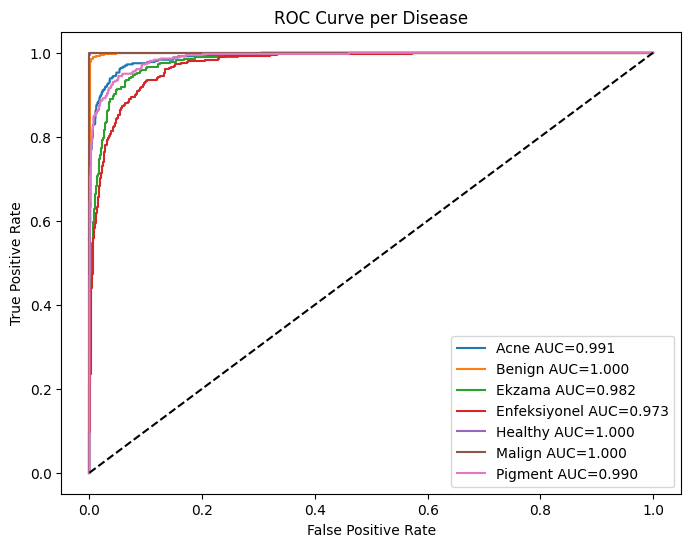

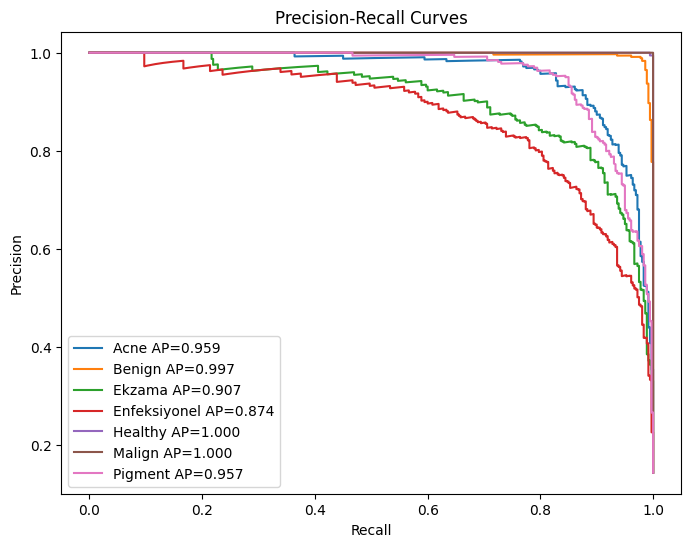

Total misclassified: 224


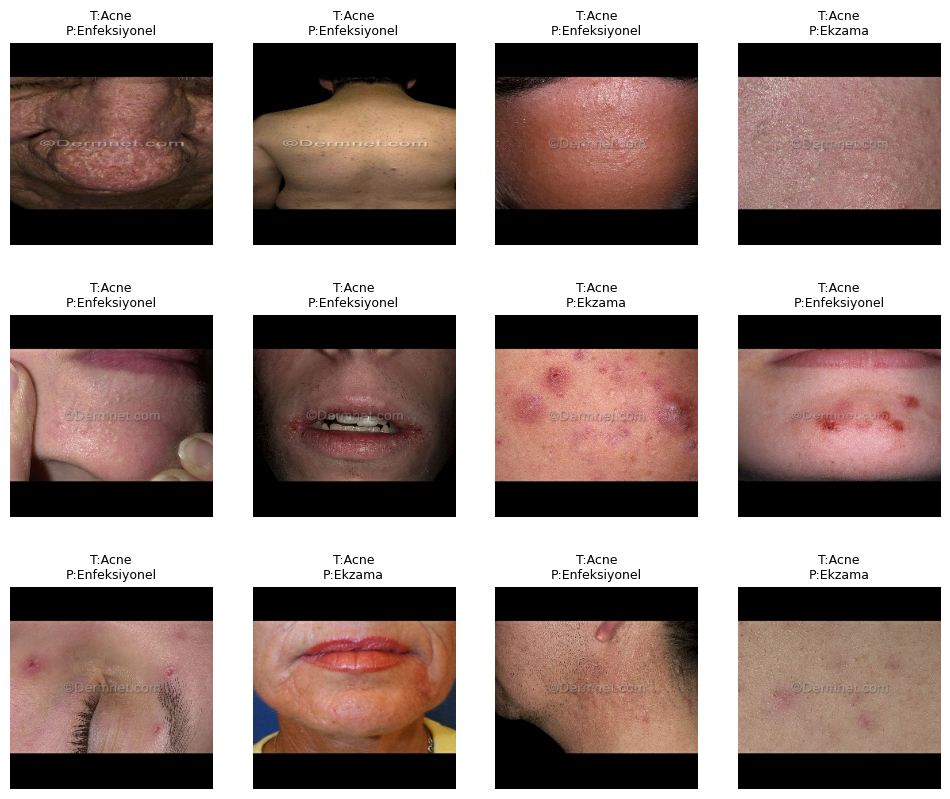

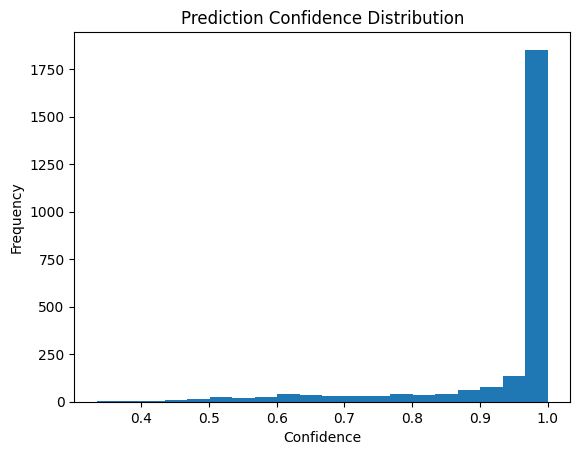

Average confidence: 0.9386862
Min confidence: 0.3348278
Max confidence: 0.99999714


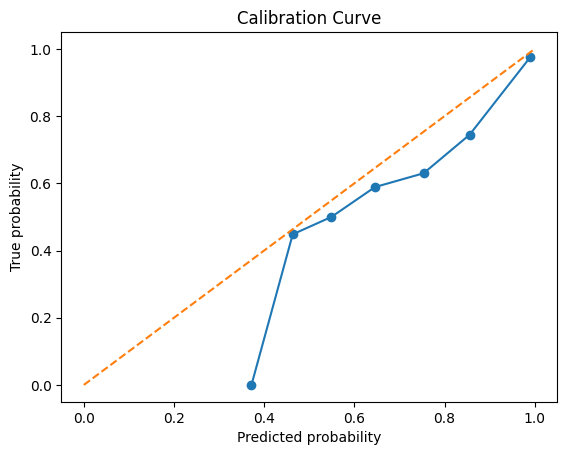

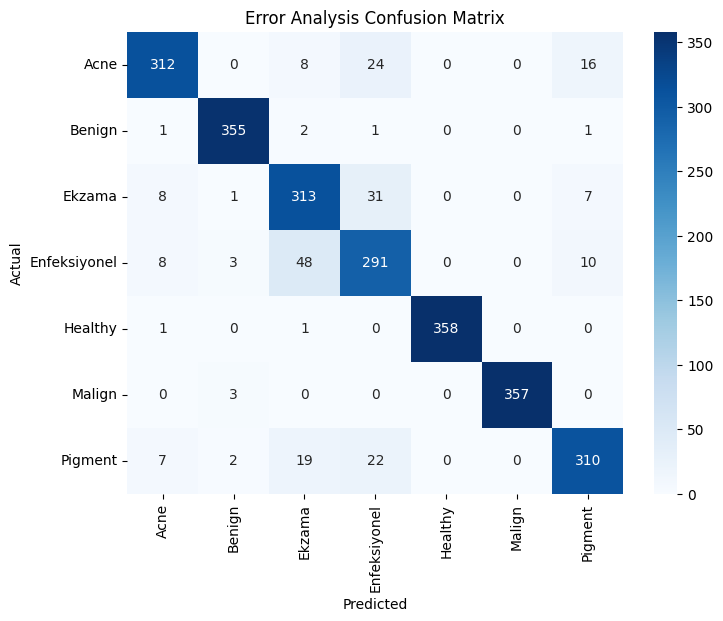

In [19]:

# SKIN MODEL COMPLETE ANALYSIS

skin_model = load_model(
r"E:\Final Project\Main Folder\Notebooks\Models\skin7_finetuned.h5"
)

skin_dataset = r"E:\Final Project\Main Folder\skin\skin_disease_classification\test"

ds_skin, skin_classes = load_dataset(
skin_dataset,
(256,256)
)

y_true_s, y_pred_s, y_prob_s, images_s = run_predictions(
skin_model,
ds_skin
)

# ROC CURVE

plot_roc(
y_true_s,
y_prob_s,
skin_classes
)

# PRECISION RECALL CURVE

plot_pr(
y_true_s,
y_prob_s,
skin_classes
)

# MISCLASSIFIED IMAGES

show_misclassified(
images_s,
y_true_s,
y_pred_s,
skin_classes
)

# RELIABILITY ANALYSIS

reliability_analysis(
y_prob_s
)

# CALIBRATION CURVE

plot_calibration(
y_true_s,
y_prob_s
)

# ERROR ANALYSIS

error_analysis(
y_true_s,
y_pred_s,
skin_classes
)



In [20]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.calibration import calibration_curve

def model_evaluation_dashboard(y_true, y_pred, y_prob, class_names, model_name="Model"):

    n_classes = len(class_names)

    y_true_bin = tf.keras.utils.to_categorical(y_true, n_classes)

    fig, axes = plt.subplots(2,2, figsize=(14,10))

      # ROC CURVE

    ax = axes[0,0]

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_prob[:,i])

        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    ax.plot([0,1],[0,1],'k--')

    ax.set_title("ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()


    # PRECISION RECALL

    ax = axes[0,1]

    for i in range(n_classes):

        precision, recall, _ = precision_recall_curve(
            y_true_bin[:,i],
            y_prob[:,i]
        )

        ax.plot(recall, precision, label=class_names[i])

    ax.set_title("Precision-Recall Curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()


     # CALIBRATION CURVE

    ax = axes[1,0]

    confidence = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)

    correct = (predictions == y_true)

    prob_true, prob_pred = calibration_curve(correct, confidence, n_bins=10)

    ax.plot(prob_pred, prob_true, marker="o", label="Model")

    ax.plot([0,1],[0,1],'--', label="Perfect")

    ax.set_title("Calibration Curve")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("True Probability")
    ax.legend()


    # CONFUSION MATRIX

    ax = axes[1,1]

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    plt.suptitle(f"{model_name} Evaluation Dashboard", fontsize=16)

    plt.tight_layout()

    plt.show()

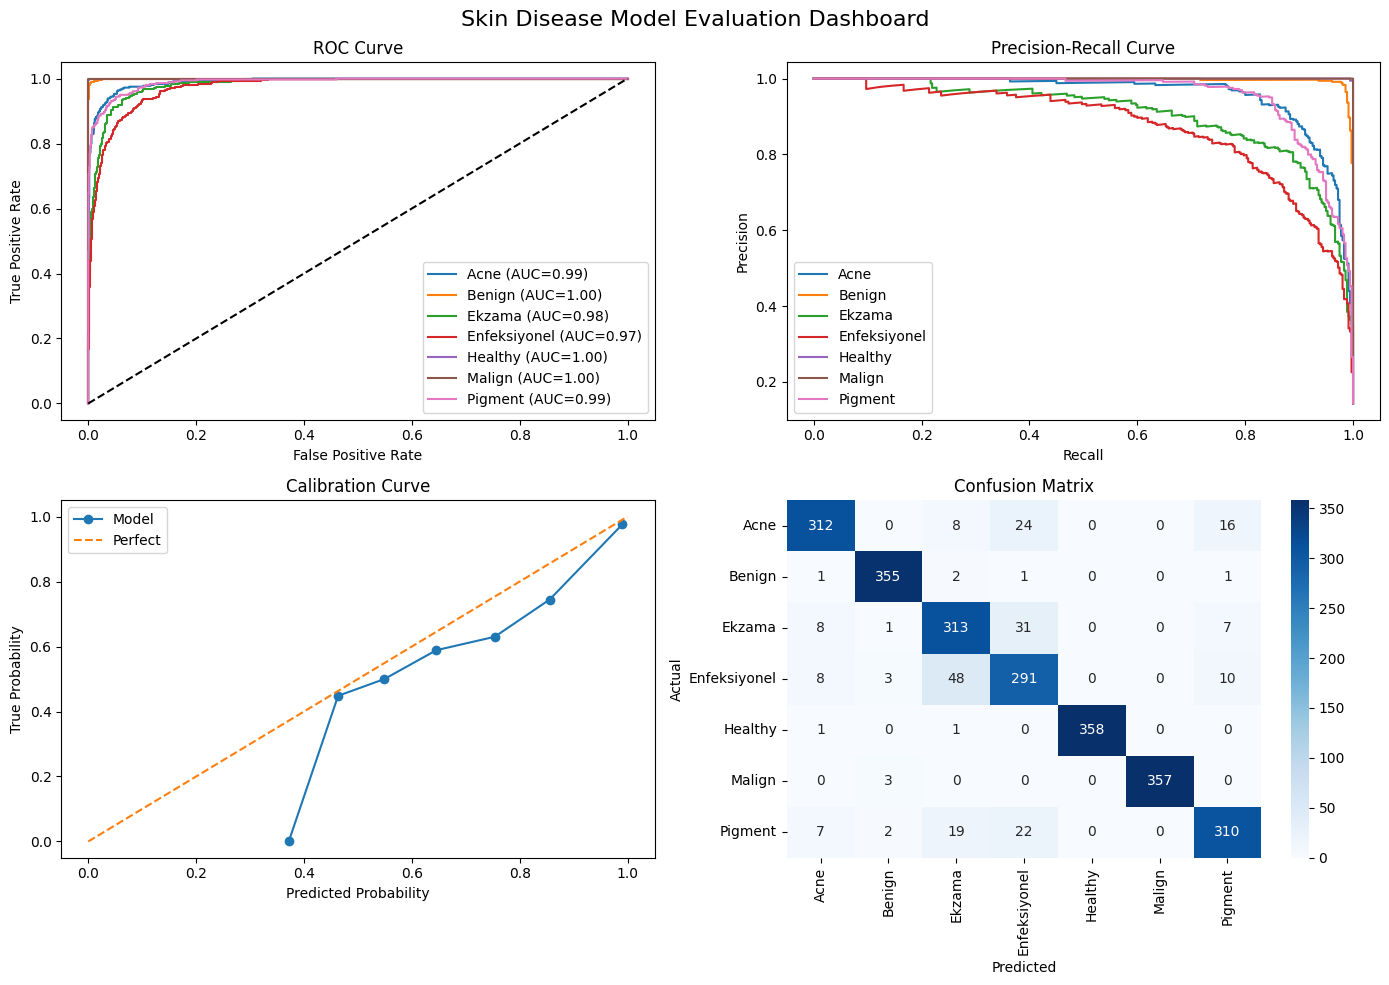

In [21]:
model_evaluation_dashboard(
    y_true_s,
    y_pred_s,
    y_prob_s,
    skin_classes,
    model_name="Skin Disease Model"
)